In [29]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [30]:
ias15_2 = pd.read_csv(
    "embryo_ias15_Jul10/famtree_2",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)
ias15_2

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
0,86.01725,4,31,4,29,8.304772e-07,5.168290e-07,3.913242e-07,0.000034,0.000029,0.000026,1.140499,0.312626
1,86.01725,4,32,4,29,7.767599e-08,5.168290e-07,3.913242e-07,0.000015,0.000029,0.000026,1.140499,0.312626
2,983.20000,2,34,15,8,9.689160e-07,5.352333e-07,4.336826e-07,0.000036,0.000029,0.000027,1.187692,0.949853


In [31]:
coll_1 = ias15_2[ias15_2['parent1_id'] == 4]
t1 = coll_1['t'].iloc[0]

In [32]:
ias15_2_archive = rebound.Simulationarchive("embryo_ias15_Jul10/archive_timestep.bin")

In [33]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [34]:
len(ias15_2_archive)

10681

In [35]:
ias15_2_times = []
ias15_2_n_bodies = []
ias15_2_masses = []
ias15_2_mass_errors = []
ias15_2_angular_momentums = []
ias15_2_L_rel_errors = []
ias15_2_Es = []
ias15_2_E_rel_errors = []
snapshot_idxs = []

for i in range(len(ias15_2_archive)):
    snap = ias15_2_archive[i]
    snapshot_idxs.append(i)
    ias15_2_times.append(snap.t)
    ias15_2_n_bodies.append(snap.N)

    Lx, Ly, Lz = snap.angular_momentum()
    ias15_2_angular_momentums.append(get_abs(Lx, Ly, Lz))
    ias15_2_Es.append(snap.energy())

    m = 0
    for j in range(len(snap.particles)):
        m += snap.particles[j].m
    
    ias15_2_masses.append(m)

for i in range(len(ias15_2_masses)):
    diff = np.abs((ias15_2_masses[i] - ias15_2_masses[0]))
    rel_diff = diff/np.abs(ias15_2_masses[0])
    ias15_2_mass_errors.append(rel_diff)

for i in range(len(ias15_2_angular_momentums)):
    diff = np.abs(ias15_2_angular_momentums[i] - ias15_2_angular_momentums[0])
    ias15_2_L_rel_errors.append(diff/np.abs(ias15_2_angular_momentums[0]))

for i in range(len(ias15_2_Es)):
    diff = np.abs(ias15_2_Es[i] - ias15_2_Es[0])
    ias15_2_E_rel_errors.append(diff/np.abs(ias15_2_Es[0]))


ias15_2_dict = {
    't': ias15_2_times,
    'N_Bodies': ias15_2_n_bodies,
    'total_masses': ias15_2_masses,
    'm_errors': ias15_2_mass_errors,
    'angular_momentums': ias15_2_angular_momentums,
    'L_rel_errors': ias15_2_L_rel_errors,
    'E': ias15_2_Es,
    'E_rel_errors': ias15_2_E_rel_errors,
    'snapshot_idx': snapshot_idxs
}

ias15_2_archive_df = pd.DataFrame(ias15_2_dict)

/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [36]:
ias15_2_archive_df

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,E,E_rel_errors,snapshot_idx
0,80.000434,31,1.000008,0.0,0.000026,0.000000e+00,-0.000592,0.000000e+00,0
1,80.001348,31,1.000008,0.0,0.000026,5.129527e-16,-0.000592,9.155505e-16,1
2,80.002262,31,1.000008,0.0,0.000026,0.000000e+00,-0.000592,4.394642e-15,2
3,80.003175,31,1.000008,0.0,0.000026,2.564763e-16,-0.000592,9.155505e-16,3
4,80.004088,31,1.000008,0.0,0.000026,3.847145e-16,-0.000592,1.831101e-15,4
...,...,...,...,...,...,...,...,...,...
10676,88.942970,31,1.000008,0.0,0.000026,1.334361e-07,-0.000550,7.064834e-02,10676
10677,88.943880,31,1.000008,0.0,0.000026,1.334361e-07,-0.000550,7.064834e-02,10677
10678,88.944791,31,1.000008,0.0,0.000026,1.334361e-07,-0.000550,7.064834e-02,10678
10679,88.945689,31,1.000008,0.0,0.000026,1.334361e-07,-0.000550,7.064834e-02,10679


In [45]:
close_up = ias15_2_archive_df[(ias15_2_archive_df['t'] < t1 + 0.001) & (ias15_2_archive_df['t'] > t1 - 0.001)]
close_up

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,E,E_rel_errors,snapshot_idx
7173,86.016317,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,1.647991e-15,7173
7174,86.016549,31,1.000008,0.0,0.000026,3.847145e-16,-0.000592,7.324404e-16,7174
7175,86.016685,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,1.281771e-15,7175
7176,86.016774,31,1.000008,0.0,0.000026,3.847145e-16,-0.000592,7.324404e-16,7176
7177,86.016838,31,1.000008,0.0,0.000026,2.564763e-16,-0.000592,3.295982e-15,7177
7178,86.016887,31,1.000008,0.0,0.000026,2.564763e-16,-0.000592,9.155505e-16,7178
7179,86.016927,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,2.380431e-15,7179
7180,86.016960,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,1.098661e-15,7180
7181,86.016988,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,3.662202e-16,7181
7182,86.017014,31,1.000008,0.0,0.000026,1.282382e-16,-0.000592,5.493303e-16,7182


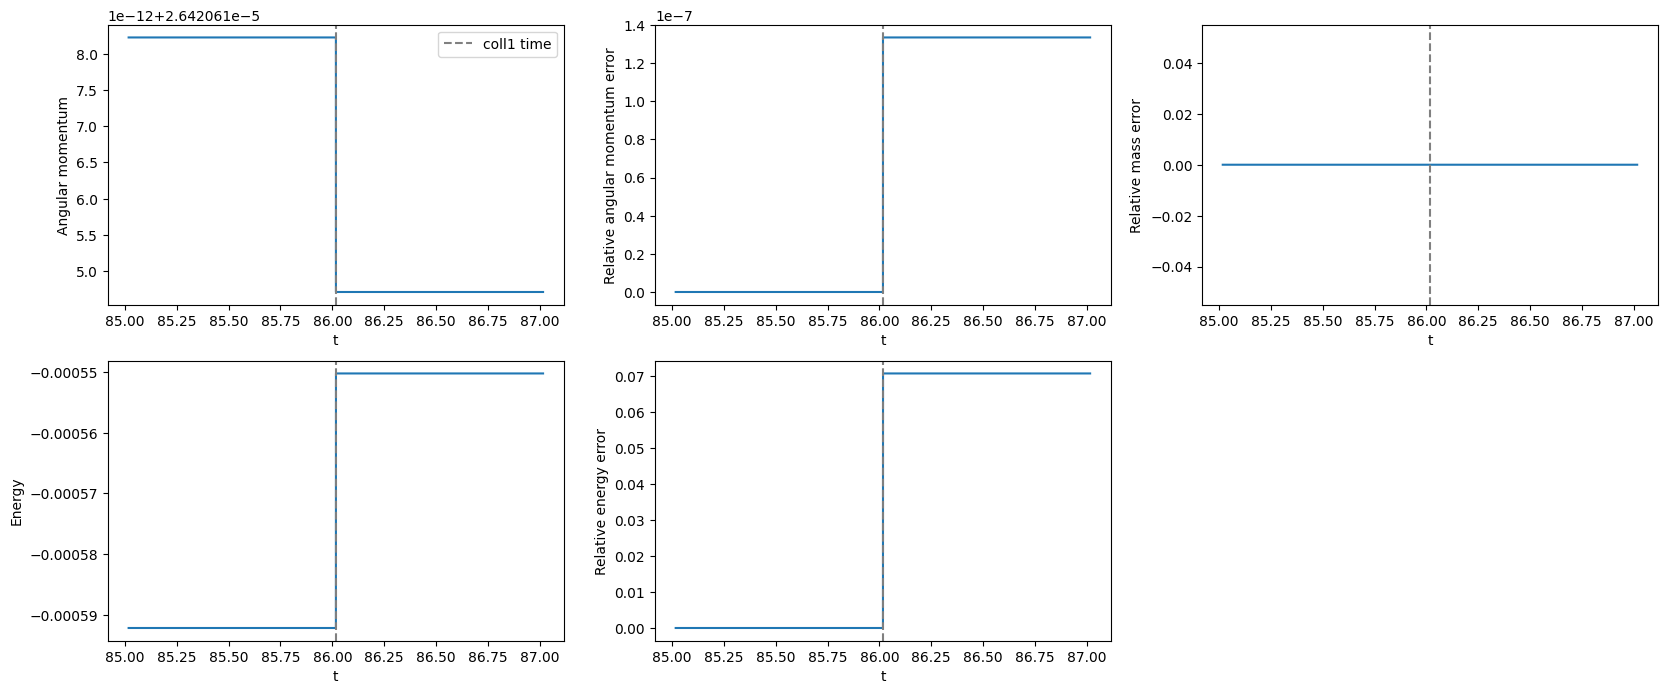

In [38]:
plt.figure(figsize=(20,8))
plt.subplot(2,3,1)
plt.plot(close_up['t'], close_up['angular_momentums'])
plt.xlabel('t')
plt.ylabel("Angular momentum")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')
plt.legend()

plt.subplot(2,3,2)
plt.plot(close_up['t'], close_up['L_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative angular momentum error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,3)
plt.plot(close_up['t'], close_up['m_errors'])
plt.xlabel('t')
plt.ylabel("Relative mass error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,4)
plt.plot(close_up['t'], close_up['E'])
plt.xlabel('t')
plt.ylabel("Energy")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,5)
plt.plot(close_up['t'], close_up['E_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative energy error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

In [46]:
idx_before = 7201
idx_after = 7202

snap_before = ias15_2_archive[idx_before]
snap_after = ias15_2_archive[idx_after]

/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [47]:
# Based on the famtree (collision output) file. Using this mass, we can find the particles right before the collision.

m_parent1 = coll_1['parent1_mass'].iloc[0]
m_parent2 = coll_1['parent2_mass'].iloc[0]
r_parent1 = coll_1['parent1_radius'].iloc[0]
r_parent2 = coll_1['parent2_radius'].iloc[0]

m_frag1 = coll_1['new_mass'].iloc[0]
m_frag2 = coll_1['new_mass'].iloc[1]

print("parent1 mass in famtree = ", m_parent1)
print("parent2 mass in famtree = ", m_parent2)

parent1 mass in famtree =  5.16829e-07
parent2 mass in famtree =  3.913242e-07


In [48]:
for i in range(snap_before.N):
    particle = snap_before.particles[i]
    if np.isclose(particle.m, m_parent1, atol=1e-11):
        parent1_before = particle
        print("parent1 found in archive, mass = ", particle.m)

    if np.isclose(particle.m, m_parent2, atol=1e-11):
        parent2_before = particle
        print("parent2 found in archive, mass = ", particle.m)

parent1 found in archive, mass =  5.168289745479957e-07
parent2 found in archive, mass =  3.9132422304382745e-07


In [49]:
for i in range(snap_after.N):
    particle = snap_after.particles[i]
    if np.isclose(particle.m, m_frag1, atol=1e-11):
        frag1 = particle
        print("frag1 mass = ", particle.m)

    if np.isclose(particle.m, m_frag2, atol=1e-11):
        frag2 = particle
        print("frag2 mass = ", particle.m)

lr_mass = np.max([frag1.m, frag2.m])
small_frags = [frag2]

frag1 mass =  8.304772094146921e-07
frag2 mass =  7.767598817713105e-08


In [50]:
coll_1

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
0,86.01725,4,31,4,29,8.304772e-07,5.168290e-07,3.913242e-07,0.000034,0.000029,0.000026,1.140499,0.312626
1,86.01725,4,32,4,29,7.767599e-08,5.168290e-07,3.913242e-07,0.000015,0.000029,0.000026,1.140499,0.312626


In [61]:
# 1. Determine Target and Projectile based on mass (Target is >= Projectile)
if parent1_before.m >= parent2_before.m:
    target = parent1_before
    projectile = parent2_before
else:
    target = parent2_before
    projectile = parent1_before

initial_mass = target.m + projectile.m

# 2. Setup initial vectors
v_target = np.array([target.vx, target.vy, target.vz])
v_proj = np.array([projectile.vx, projectile.vy, projectile.vz])
r_target = np.array([target.x, target.y, target.z])
r_proj = np.array([projectile.x, projectile.y, projectile.z])

v_com = (target.m * v_target + projectile.m * v_proj) / initial_mass
r_com = (target.m * r_target + projectile.m * r_proj) / initial_mass

# 3. Calculate internal expansion velocity & Separation Distance
v_lr = np.linalg.norm(v_com)

r_tot = target.r + projectile.r
separation_distance_scale = 4.0 # Default value from C code
separation_distance = separation_distance_scale * r_tot

# 4. Relative vectors & Collision Plane
dv = v_target - v_proj
dr = r_target - r_proj
unit_dv = dv / np.linalg.norm(dv)

normal_coll_plane = np.cross(dv, dr)
mag_ncp = np.linalg.norm(normal_coll_plane)

# Collinear fallback (replicating C code lines 241-250)
if mag_ncp < 1e-15:
    arb_vec = np.cross(unit_dv, np.array([1.0, 0.0, 0.0]))
    if np.linalg.norm(arb_vec) < 1e-15:
        arb_vec = np.cross(unit_dv, np.array([0.0, 1.0, 0.0]))
    normal_coll_plane = arb_vec
    mag_ncp = np.linalg.norm(normal_coll_plane)

normal_coll_plane = normal_coll_plane / mag_ncp
normal_to_vrel = np.cross(dv, normal_coll_plane)
normal_to_vrel = normal_to_vrel / np.linalg.norm(normal_to_vrel)

# 5. Map fragments 
# Determine if a second largest remnant (slr_mass) exists to assign it to j=0
slr_mass = 0
n_big_frag = 1 if slr_mass > 0 else 0
n_frag = len(small_frags) + n_big_frag
theta_sep = (2.0 * np.pi) / n_frag

# 6. Assign Initial Vectors and Track COM/Momentum
mxsum = lr_mass * r_com
mvsum = lr_mass * v_com 

target_r_raw = r_com
target_v_raw = v_com 

frag_kinematics_raw = []

# Add Big Fragment (SLR) if it exists (j=0)
if n_big_frag == 1:
    r_slr_raw = r_com + separation_distance * unit_dv # cos(0)=1, sin(0)=0
    v_slr_mag = v_lr * np.sqrt(lr_mass / slr_mass)
    v_slr_raw = v_com + v_slr_mag * unit_dv
    
    frag_kinematics_raw.append({'mass': slr_mass, 'r_raw': r_slr_raw, 'v_raw': v_slr_raw, 'name': 'Second Largest Remnant'})
    
    mxsum += slr_mass * r_slr_raw
    mvsum += slr_mass * v_slr_raw

# Add Small Fragments
for j, frag in enumerate(small_frags, start=1):
    frag_velocity_mag = v_lr * np.sqrt(lr_mass / frag.m)
    
    cos_t = np.cos(theta_sep * j)
    sin_t = np.sin(theta_sep * j)
    
    r_frag_raw = r_com + separation_distance * (cos_t * unit_dv + sin_t * normal_to_vrel)
    v_frag_raw = v_com + frag_velocity_mag * (cos_t * unit_dv + sin_t * normal_to_vrel)
    
    frag_kinematics_raw.append({'mass': frag.m, 'r_raw': r_frag_raw, 'v_raw': v_frag_raw, 'name': f'Small Fragment {j}'})
    
    mxsum += frag.m * r_frag_raw
    mvsum += frag.m * v_frag_raw

# 7. COM and Momentum Offset Correction 
xoff = r_com - (mxsum / initial_mass)
voff = v_com - (mvsum / initial_mass)

# The "New way": uniform adjustment for all particles
target_r_final = target_r_raw + xoff
target_v_final = target_v_raw + voff

print("--- LARGEST REMNANT ---")
print(f"Expected r: {target_r_final}, abs = {get_abs(target_r_final[0], target_r_final[1], target_r_final[2])}")
print(f"Expected v: {target_v_final}, abs = {get_abs(target_v_final[0], target_v_final[1], target_v_final[2])}\n")

print("--- FRAGMENTS ---")
for frag_dict in frag_kinematics_raw:
    r_frag_final = frag_dict['r_raw'] + xoff 
    v_frag_final = frag_dict['v_raw'] + voff 
    
    name = frag_dict['name']
    print(f"[{name}] Expected r: {r_frag_final}, abs = {get_abs(r_frag_final[0], r_frag_final[1], r_frag_final[2])}")
    print(f"[{name}] Expected v: {v_frag_final}, abs = {get_abs(v_frag_final[0], v_frag_final[1], v_frag_final[2])}\n")

--- LARGEST REMNANT ---
Expected r: [ 0.3531071  -0.06647968 -0.00203486], abs = 0.35931645501950116
Expected v: [ 4.28272374 11.11771919 -1.5734478 ], abs = 12.017534711243389

--- FRAGMENTS ---
[Small Fragment 1] Expected r: [ 0.35293285 -0.06654078 -0.00191188], abs = 0.3591558563421447
[Small Fragment 1] Expected v: [-22.67545638   1.66484556  17.45312561], abs = 28.6628614470721




 lr x, y, z = 3.531003e-01 -6.644252e-02 -2.024119e-03 

 lr vx, vy, vz = 1.975706e+00 1.030943e+01 5.393658e-02 

 frag_1 x, y, z = 3.529272e-01 -6.650606e-02 -1.900772e-03 

 frag_1 vx, vy, vz = -2.480705e+01 4.790517e-01 1.913685e+01 

In [59]:
print(f"parent1 vx = {parent1_before.vx}, vy = {parent1_before.vy}, vz = {parent1_before.vz}")
print(f"parent2 vx = {parent2_before.vx}, vy = {parent2_before.vy}, vz = {parent2_before.vz}\n")

print(f"frag1 x = {frag1.x}, y = {frag1.y}, z = {frag1.z}")
print(f"frag2 x = {frag2.x}, y = {frag2.y}, z = {frag2.z}\n")

print(f"frag1 vx = {frag1.vx}, vy = {frag1.vy}, vz = {frag1.vz}, |v| = {get_abs(frag1.vx, frag1.vy, frag1.vz)}")
print(f"frag2 vx = {frag2.vx}, vy = {frag2.vy}, vz = {frag2.vz}, |v| = {get_abs(frag2.vx, frag2.vy, frag2.vz)}")

parent1 vx = 1.605597005608445, vy = 10.178985914935184, vz = 0.3160175887827301
parent2 vx = 2.4673834746864323, vy = 10.481170949463635, vz = -0.2922149937914139

frag1 x = 0.3531151315912067, y = -0.06643708617611525, z = -0.002034669005441249
frag2 x = 0.35294201464855607, y = -0.06650062724686767, z = -0.0019113219300434326

frag1 vx = 4.266483984688055, vy = 11.150240439376502, vz = -1.5782591775032073, |v| = 12.042493490921215
frag2 vx = -22.516273582035765, vy = 1.319861809560404, vz = 17.504649556684132, |v| = 28.550610629542405


Based on the print statements, these are target and projectile and com velocities and positions:

pi_mass = 5.168290e-07, pj_mass = 3.913242e-07

target_mass = 5.168290e-07, proj_mass = 3.913242e-07

com.x = 3.531003e-01, com.y = -6.644252e-02, com.z = -2.024119e-03

com.vx = 1.975706e+00, com.vy = 1.030943e+01, com.vz = 5.393658e-02



target.x = 3.531148e-01, target.y = -6.642956e-02, target.z = -2.037569e-03

target.vx = 1.592233e+00, target.vy = 1.016868e+01, target.vz = 3.271638e-01

proj.x = 3.530812e-01, proj.y = -6.645963e-02, proj.z = -2.006355e-03

proj.vx = 2.482166e+00, proj.vy = 1.049532e+01, proj.vz = -3.069196e-01

They do not match ours.


In [53]:
print("v_com expected = ", v_com)
print("r_com expected = ", r_com)

v_com expected =  [ 1.97694175 10.30919778  0.05392949]
r_com expected =  [ 0.3530922  -0.06648491 -0.00202434]


In [54]:
print("t before = ", snap_before.t)

print("r_target from archive = ", r_target)
print("v_target from archive = ", v_target)

print("r_projectile from archive = ", r_proj)
print("v_projectile from archive = ", v_proj)

t before =  86.01724597721352
r_target from archive =  [ 0.35310822 -0.06647139 -0.00203889]
v_target from archive =  [ 1.60559701 10.17898591  0.31601759]
r_projectile from archive =  [ 0.35307103 -0.06650276 -0.00200512]
v_projectile from archive =  [ 2.46738347 10.48117095 -0.29221499]


From print statements:

sim.t = 8.601725e+01

target.x = 3.531148e-01, target.y = -6.642956e-02, target.z = -2.037569e-03

target.vx = 1.592233e+00, target.vy = 1.016868e+01, target.vz = 3.271638e-01

proj.x = 3.530812e-01, proj.y = -6.645963e-02, proj.z = -2.006355e-03

proj.vx = 2.482166e+00, proj.vy = 1.049532e+01, proj.vz = -3.069196e-01